In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI(
    openai_api_base="https://openrouter.ai/api/v1",
    model="openrouter/free"
)

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[str], add_messages]

In [6]:
def chat(state: ChatState):
    messages = state["messages"]

    response = model.invoke(messages)

    return {"messages": [response]}

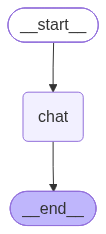

In [7]:
graph = StateGraph(ChatState)

graph.add_node("chat", chat)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [12]:
thread_id = 1
while True:
    user_message = input("Type here:")
    print(f"User: {user_message}")

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    config = {"configurable": {"thread_id": thread_id}}

    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)

    print(f"""Ai: {response["messages"][-1].content}""")


User: hi
Ai: Hello, Hamza! How can I assist you today? 😊
User: what is my name
Ai: Your name is Hamza! 😊 We discussed this earlier in our conversation. How can I help you today?
User: bye


In [13]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='0aea59bd-1e9c-43ad-93eb-4484b7cb1d18'), AIMessage(content='Hi there! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 21, 'total_tokens': 105, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 91, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'inclusionai/ling-3.0-flash-sante:free', 'system_fingerprint': None, 'id': 'gen-1790093406-QbD4utaEQMk38yy7LWtS', 